In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

%cd /g/data/w42/dr6273/work/wind_drought/
import utils

/g/data/w42/dr6273/work/wind_drought


In [2]:
import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [3]:
%load_ext autoreload
%autoreload 2

### BARRA-R2 wind speed data for MJJ

In [4]:
regions = ['nem-2030', 'se-2030', 'swis', 'nwis']

In [5]:
obs_infiles = [
    '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_' + i + '.nc'
    for i in regions
]

In [6]:
obs_infiles

['/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_nem-2030.nc',
 '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_se-2030.nc',
 '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_swis.nc',
 '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_nwis.nc']

In [29]:
obs_dict = {
    r: xr.open_dataset(infile) for r, infile in zip(regions, obs_infiles)
}

In [30]:
obs_dict.keys()

dict_keys(['nem-2030', 'se-2030', 'swis', 'nwis'])

In [31]:
obs_dict['nem-2030']

<xarray.Dataset> Size: 68kB
Dimensions:  (time: 4232)
Coordinates:
  * time     (time) datetime64[ns] 34kB 1980-05-01T12:00:00 ... 2025-07-31T12...
Data variables:
    sfcWind  (time) float64 34kB ...
Attributes: (12/61)
    CDI:                       Climate Data Interface version 2.4.3 (https://...
    Conventions:               CF-1.10, ACDD-1.3
    source:                    Data from Met Office Unified Model (UM, versio...
    institution:               Bureau of Meteorology
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        88.48
    geospatial_lon_max:        207.39
    geospatial_lon_units:      degrees_east
    history:                   Mon May 11 11:26:42 2026: cdo mergetime sfcWin...
    CDO:                       Climate Data Operators version 2.4.3 (https://...

In [26]:
def plot_ws_hist(ax, da, region):
    """ Histogram of wind speed """
    bins = np.arange(0, 9.5, 0.5)
    ax.hist(da, bins=bins, density=True, rwidth=0.9, label=region, color='tab:blue', alpha=0.5)
    
    pctl10 = np.percentile(da, 10)
    ax.axvline(pctl10, color='tab:blue', label='10th percentile')
    
    ax.set_xlabel('daily average surface wind speed [m/s]')
    ax.set_ylabel('probability density [s/m]')
    ax.set_title('BARRA-R2 ' + region, fontsize=10)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 0.6)
    ax.legend()

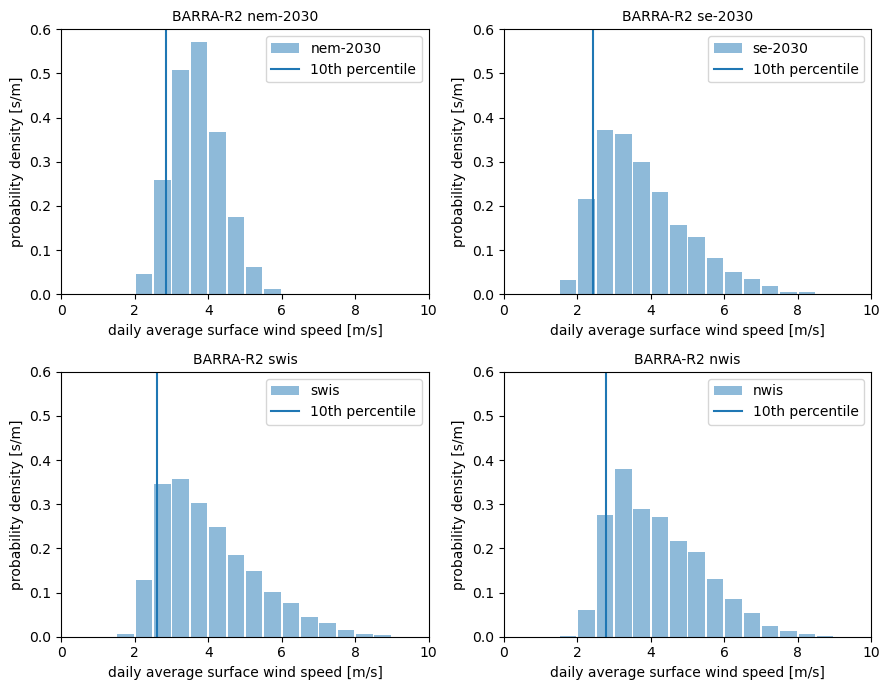

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(9,7))
for i, (r, da) in enumerate(obs_dict.items()):
    ax = axes.flatten()[i]
    plot_ws_hist(ax, da['sfcWind'], r)
plt.tight_layout()

### Calculate annual maximum wind drought duration (WDDx)

In [34]:
wddx_obs = {}
for r, da in obs_dict.items():
    pctl10 = np.percentile(da['sfcWind'], 10)
    wddx_obs[r] = utils.calc_wddx_obs(da, pctl10)

In [43]:
def plot_wddx_ts(ax, da, region):
    """ Plot WDDx time series """
    
    da['event_length'].plot(ax=ax, label=region, color='tab:blue', alpha=1)
    ax.set_title('WDDx ' + region, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Event length [d]')
    ax.set_ylim(0,9)

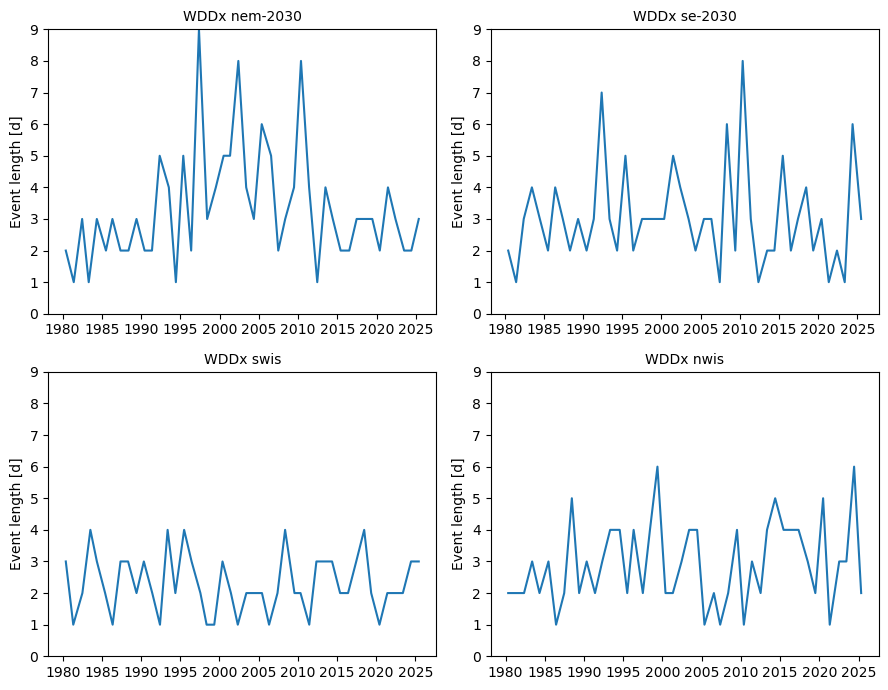

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(9,7))
for i, (r, da) in enumerate(wddx_obs.items()):
    ax = axes.flatten()[i]
    plot_wddx_ts(ax, da, r)
plt.tight_layout()

In [52]:
def plot_wddx_hist(ax, da, region):
    """ Histogram of WDDx """
    bins = np.arange(0.5, 16.5, 1)
    ax.hist(da['event_length'], bins=bins, density=True, rwidth=0.9, label=region, color='tab:blue', alpha=0.5)
    
    ax.set_xlabel('Anual maximum wind drought duration [d]')
    ax.set_ylabel('probability density [1/d]')
    ax.set_title('BARRA-R2 ' + region, fontsize=10)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 0.5)
    ax.legend()

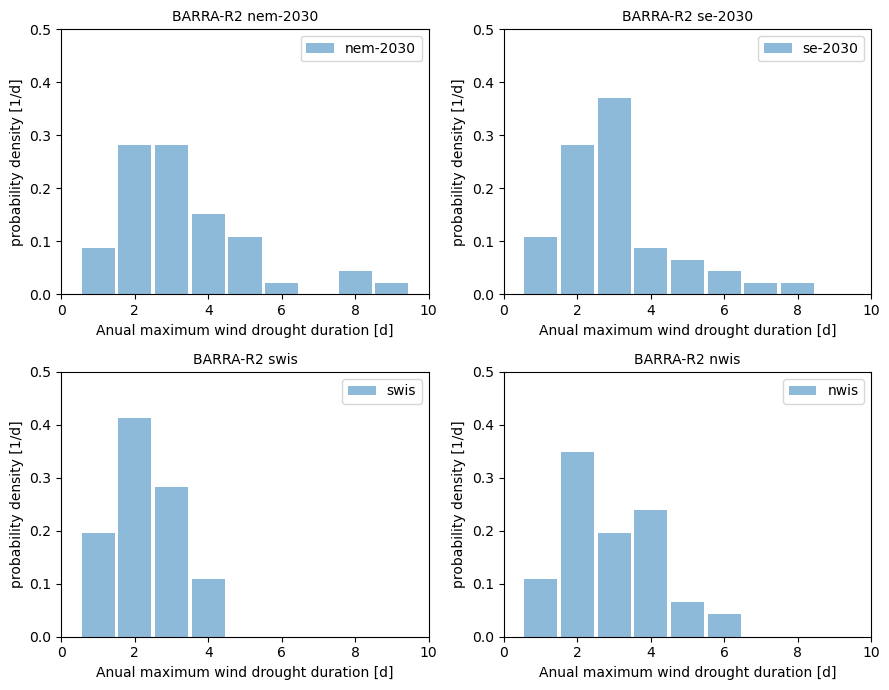

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(9,7))
for i, (r, da) in enumerate(wddx_obs.items()):
    ax = axes.flatten()[i]
    plot_wddx_hist(ax, da, r)
plt.tight_layout()

### Longest droughts

In [74]:
droughts_dfs = {}
for r, da in wddx_obs.items():
    years = da['event_start'].dt.year.values
    df = pd.DataFrame(index=years)
    df['WDDx'] = da['event_length'].values.astype('int32')
    df['start_date'] = pd.to_datetime(da['event_start'].dt.strftime('%Y-%m-%d'))
    df['end_date'] = pd.to_datetime(da['event_start'].dt.strftime('%Y-%m-%d')) + pd.to_timedelta(df['WDDx'] - 1, unit='D')
    droughts_dfs[r] = df.set_index('start_date')

In [75]:
droughts_dfs['nem-2030'].sort_values(['WDDx'], ascending=False).head(n=10)

,WDDx,end_date
start_date,,
1997-05-16,9,1997-05-24
2002-05-22,8,2002-05-29
2010-05-14,8,2010-05-21
2005-05-14,6,2005-05-19
1992-05-14,5,1992-05-18
2001-05-01,5,2001-05-05
2000-07-06,5,2000-07-10
2006-07-23,5,2006-07-27
1995-05-17,5,1995-05-21


In [76]:
wddx_p50 = {r: np.percentile(da['event_length'], 50) for r, da in wddx_obs.items()}
wddx_p80 = {r: np.percentile(da['event_length'], 80) for r, da in wddx_obs.items()}

In [77]:
print(wddx_p50)
print(wddx_p80)

{'nem-2030': 3.0, 'se-2030': 3.0, 'swis': 2.0, 'nwis': 3.0}
{'nem-2030': 4.0, 'se-2030': 4.0, 'swis': 3.0, 'nwis': 4.0}


In [78]:
droughts_subset = {}
for r, df in droughts_dfs.items():
    droughts_subset[r] = {}
    
    min_len = wddx_p80[r] # minimum length for a 'top drought' is >80th percentile.
    
    top_df = df[df['WDDx'] > min_len].sort_values(['WDDx'], ascending=False)
    
    other_df = df[
        (df['WDDx'] <= min_len) & (df['WDDx'] >= wddx_p50[r]) # compare to droughts between 50th and 80th percentiles
        ].sort_values(['WDDx'], ascending=False)

    droughts_subset[r]['top'] = top_df
    droughts_subset[r]['other'] = other_df

In [79]:
droughts_subset['nem-2030']['top']

,WDDx,end_date
start_date,,
1997-05-16,9,1997-05-24
2002-05-22,8,2002-05-29
2010-05-14,8,2010-05-21
2005-05-14,6,2005-05-19
1992-05-14,5,1992-05-18
1995-05-17,5,1995-05-21
2000-07-06,5,2000-07-10
2001-05-01,5,2001-05-05
2006-07-23,5,2006-07-27


### Synoptic Weather Types

In [80]:
# Australian Synoptic Weather Type data from forked repository
swt = pd.read_csv(
    "../Australian-synoptic-weather-types/SWT_climatology/SWT_climatology.csv",
    index_col=0,
    parse_dates=True
)

In [81]:
ordered_SWTs = [
    "WH-A", "WH-B", "WH-C", "WH-D",
    "CH-A", "CH-B",
    "EH-A", "EH-B", "EH-C", "EH-D", "EH-E",
    "TH-A", "TH-B", "TH-C",
    "FH-A", "FH-B", "FH-C",
    "WCT-A", "WCT-B",
    "COL-A", "COL-B", "COL-C", "COL-D", "COL-E", "COL-F",
    "AM-A", "AM-B", "AM-C", "AM-D", "AM-E"
]

In [82]:
missing_values = set(ordered_SWTs) - set(swt["assigned_SWT"].dropna().unique())

if missing_values:
    print("Missing from swt:", sorted(missing_values))
else:
    print("All ordered_SWTs are present in swt.")

All ordered_SWTs are present in swt.


In [83]:
# Plotting bars for each SWT category in the groups
colors=[
    (134/255,0/255,34/255),(241/255,0/255,241/255),(255/255,134/255,255/255),(255/255,241/255,255/255), #Pink WH
    (255/255,204/255,51/255),(255/255,245/255,204/255), #Yellow CH
    (153/255,15/255,15/255),(178/255,44/255,44/255),(204/255,81/255,81/255),(229/255,126/255,126/255),(255/255,178/255,178/255), #Red EH
    (153/255,84/255,15/255),(204/255,142/255,81/255),(255/255,216/255, 178/255), #Brown TH
    (107/255,153/255,15/255),(163/255,204/255,81/255),(195/255,229/255,126/255), #Green FH (133/255,178/255,44/255),
    (66/255,44/255,178/255),(143/255,126/255,229/255), #Purple WCT
    (5/255,67/255,113/255),(15/255,107/255,153/255),(44/255,133/255,178/255),(81/255,163/255,204/255),(126/255,195/255,229/255),(178/255,229/255,255/255), #Blue COL
    (0/255,60/255,48/255),(1/255,102/255,95/255),(53/255,151/255,143/255),(128/255,205/255,193/255),(199/255,234/255,229/255)
]

In [84]:
colour_by_swt = dict(zip(ordered_SWTs, colors))

Get SWT occurrences during droughts

In [85]:
# top_events = {
#     top_droughts.iloc[i]['start_date'].strftime('%Y-%m-%d'): (
#         top_droughts.iloc[i]['start_date'].strftime('%Y-%m-%d'),
#         top_droughts.iloc[i]['end_date'].strftime('%Y-%m-%d')
#     ) for i in range(top_droughts.shape[0])
# }

# other_events = {
#     other_droughts.iloc[i]['start_date'].strftime('%Y-%m-%d'): (
#         other_droughts.iloc[i]['start_date'].strftime('%Y-%m-%d'),
#         other_droughts.iloc[i]['end_date'].strftime('%Y-%m-%d')
#     ) for i in range(other_droughts.shape[0])
# }

In [89]:
droughts_subset['nem-2030']['top']

,WDDx,end_date
start_date,,
1997-05-16,9,1997-05-24
2002-05-22,8,2002-05-29
2010-05-14,8,2010-05-21
2005-05-14,6,2005-05-19
1992-05-14,5,1992-05-18
1995-05-17,5,1995-05-21
2000-07-06,5,2000-07-10
2001-05-01,5,2001-05-05
2006-07-23,5,2006-07-27


In [90]:
for a, b in zip(droughts_subset['nem-2030']['top'].index, droughts_subset['nem-2030']['top']['end_date']):
    print(a,b)

1997-05-16 00:00:00 1997-05-24 00:00:00
2002-05-22 00:00:00 2002-05-29 00:00:00
2010-05-14 00:00:00 2010-05-21 00:00:00
2005-05-14 00:00:00 2005-05-19 00:00:00
1992-05-14 00:00:00 1992-05-18 00:00:00
1995-05-17 00:00:00 1995-05-21 00:00:00
2000-07-06 00:00:00 2000-07-10 00:00:00
2001-05-01 00:00:00 2001-05-05 00:00:00
2006-07-23 00:00:00 2006-07-27 00:00:00


In [105]:
swt_distributions = {}
for r, drought_dict in droughts_subset.items():
    swt_distributions[r] = {}

    for drought_type, df in drought_dict.items():
        distributions = {}

        for start, end in zip(df.index, df['end_date']):
            event_swts = swt.loc[start:end, "assigned_SWT"]

            distributions[start] = (
                event_swts
                .value_counts(normalize=False)  # proportions rather than counts
                .reindex(ordered_SWTs, fill_value=0)
            )

        swt_distributions[r][drought_type] = pd.DataFrame(distributions).T

In [152]:
[d.strftime("%Y") for d in swt_distributions['nem-2030']['other'].index]

['2009',
 '2013',
 '2021',
 '1993',
 '1999',
 '2003',
 '2011',
 '2022',
 '2019',
 '2018',
 '2017',
 '2014',
 '1982',
 '1984',
 '2008',
 '2004',
 '1998',
 '1989',
 '1986',
 '2025']

In [153]:
swt_distributions['nem-2030']['other'].index.strftime("%Y")

Index(['2009', '2013', '2021', '1993', '1999', '2003', '2011', '2022', '2019',
       '2018', '2017', '2014', '1982', '1984', '2008', '2004', '1998', '1989',
       '1986', '2025'],
      dtype='object')

In [164]:
def plot_swt_by_event(ax, distributions, region, drought_type='top'):
    """ Plot distribution of SWT occurrences for each event """
    from matplotlib.patches import Patch
    import matplotlib.dates as mdates
    
    ax = distributions[region][drought_type].plot(
        ax=ax,
        kind="bar",
        stacked=True,
        color=[colour_by_swt[swt] for swt in distributions[region][drought_type].columns],
        width=0.85,
        edgecolor="none",
    )

    ax.set_xlabel("Event start")
    ax.set_ylabel("Event days")
    
    present_swt_values = [
        swt for swt in ordered_SWTs
        if distributions[region][drought_type][swt].sum() > 0
    ]
    
    legend_handles = [
        Patch(
            facecolor=colour_by_swt[swt],
            label=swt
        )
        for swt in present_swt_values
    ]
    
    ax.legend(
        handles=legend_handles,
        bbox_to_anchor=(0.5, 1),
        loc="upper left",
        # title="SWT",
        ncols=4,
        fontsize=9,
        frameon=False
    )

    labels = distributions[region][drought_type].index.strftime("%Y-%m-%d")#ax.get_xticklabels()
    ax.set_xticklabels(labels)
    ax.tick_params(axis='x', labelrotation=45)
    
    min_len = str(distributions[region][drought_type].iloc[-1].sum())
    ax.set_title('a) ' + region + r' SWT occurrences for each wind lull $\geq $' + min_len + ' days duration', loc='left', fontsize=10)

In [165]:
def plot_swt_hist(ax, distributions, region, show_other=True):
    """ histogram of SWT occurrences during all events """

    top_swt_counts = (
        distributions[region]['top']
        .sum(axis=0)
        .reindex(ordered_SWTs, fill_value=0)
    )
    
    other_swt_counts = (
        distributions[region]['other']
        .sum(axis=0)
        .reindex(ordered_SWTs, fill_value=0)
    )
    
    # climatological counts
    swt_mjj = swt[swt.index.month.isin([5, 6, 7])]
    clim_counts = (
        swt_mjj["assigned_SWT"]
        .value_counts()
        .reindex(ordered_SWTs, fill_value=0)
    )
    
    # Convert to frequencies
    top_event_freq = top_swt_counts / top_swt_counts.sum()
    other_event_freq = other_swt_counts / other_swt_counts.sum()
    clim_freq = clim_counts / clim_counts.sum()
    
    x = range(len(ordered_SWTs))
    
    ax.bar(
        x,
        top_event_freq,
        color=[colour_by_swt[swt] for swt in ordered_SWTs],
        alpha=0.8,
        label="Top events",
    )

    if show_other:
        ax.plot(
            x,
            other_event_freq,
            color="black",
            marker="s",
            ls="--",
            markersize=5,
            linewidth=.8,
            label="Other events",
        )
        
    ax.plot(
        x,
        clim_freq,
        color="black",
        marker="o",
        markersize=5,
        linewidth=.8,
        label="Climatology",
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_SWTs, rotation=45, ha="right")
    ax.set_xlabel('SWT')
    ax.set_ylabel("Relative frequency [-]")
    ax.legend(fontsize=9)

    min_len = str(distributions[region]['top'].iloc[-1].sum())
    ax.set_title('b) ' + region + r' SWT occurrences for all wind lulls $\geq $' + min_len + ' days duration', loc='left', fontsize=10)

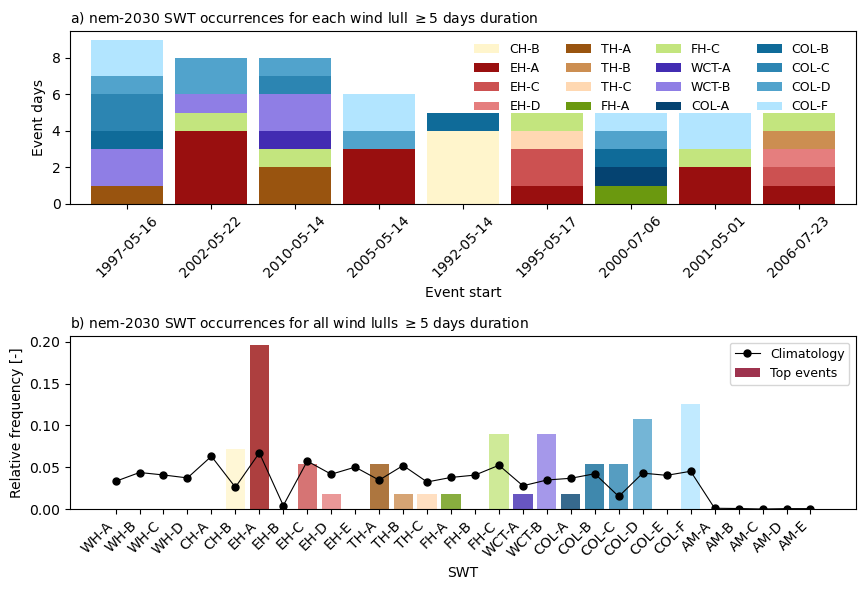

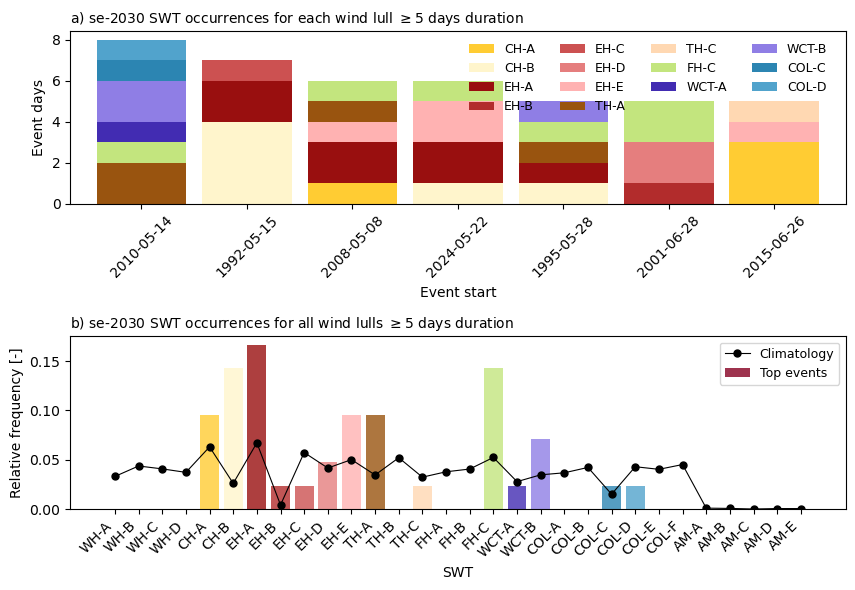

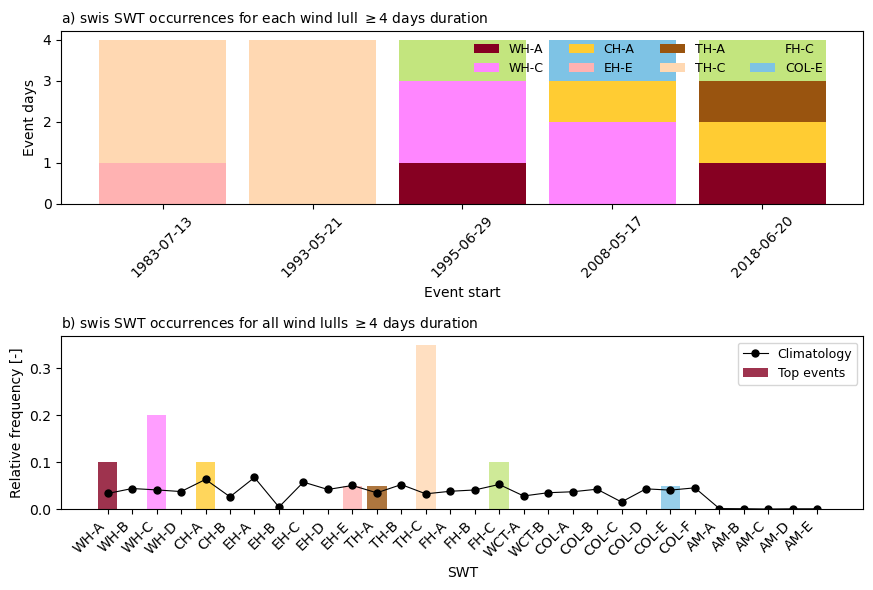

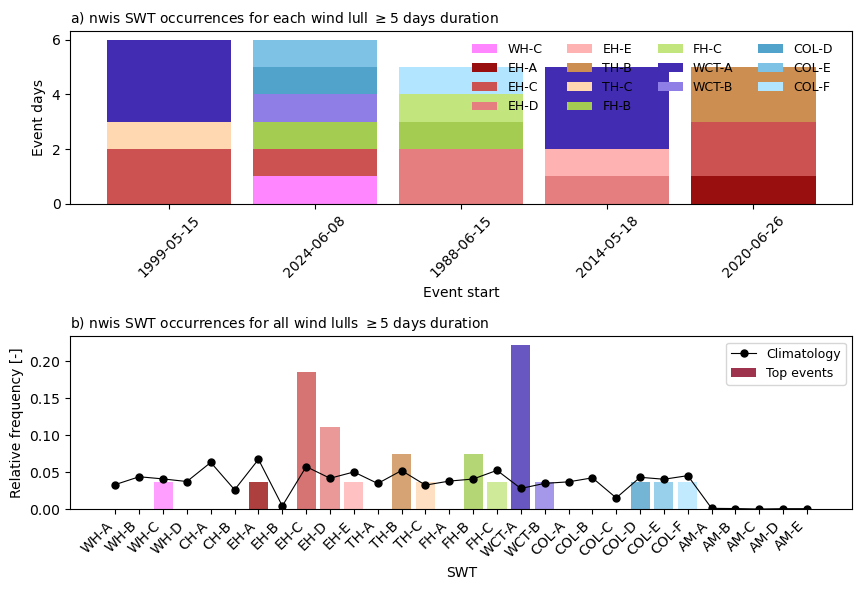

In [166]:
for r in regions:
    fig, axes = plt.subplots(2, 1, figsize=(9, 6))
    
    ax = axes[0]
    plot_swt_by_event(ax, swt_distributions, r, drought_type='top')
    
    ax = axes[1]
    plot_swt_hist(ax, swt_distributions, r, show_other=False)
    
    plt.tight_layout()

### Gridded data

#### tasmax

In [14]:
# tasmax_path = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/day/tasmax/latest/'

We want anomalies, so compute the climatology for MJJ

MSLP (psl)

In [46]:
psl_path = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/day/psl/latest/'

Wind speed (sfcWind)

In [47]:
sfcWind_path = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/day/sfcWind/latest/'

### Composite plots

In [48]:
def sfcWind_slice(da, event_start, event_duration, days_before, days_after):
    """ Return da around event """
    time_slice = pd.date_range(
        pd.to_datetime(event_start) - pd.DateOffset(days=days_before),
        pd.to_datetime(event_start) + pd.DateOffset(days=event_duration + days_after - 1)
    ) + pd.Timedelta(hours=12)
    return da.sel(time=time_slice)

In [49]:
def plot_ts(ax, da, thresh):
    """ Plot wind drought event time series """
    da.plot(marker='o')
    ax.axhline(thresh, c="k")
    ax.fill_between(x=da.time, y1=da, y2=thresh, where=da<thresh, interpolate=True, alpha=0.5)

In [50]:
def barra_var_for_month(var_name, var_path, year, month):
    """
    BARRA-R2 data for a given month

    var_name: str, name of variable
    var_path: str, path to variable
    year: str, year to open
    month: str, month to open
    """
    var_fname = var_name + '_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_'
    return xr.open_mfdataset(
        var_path + var_fname + year + month + '-' + year + month + '.nc'
    )[var_name]

In [51]:
def barra_var_for_event(event_start, event_duration, var_name, var_path):
    """
    BARRA-R2 data during an event

    event_start: str, start day of event in format yyyy-mm-dd
    event_duration: int or float, duration of event
    var_name: str, name of variable
    var_path: str, path to variable
    """
    year, month, day = event_start.split('-')
    next_month = (int('12')+1) % 12
    next_month = f"{next_month:02}"

    # Data for start month, and next month, in case event lasts into next month
    var_month = barra_var_for_month(var_name, var_path, year, month)
    var_month_next = barra_var_for_month(var_name, var_path, year, next_month)
    var_month = xr.concat([var_month, var_month_next], dim="time")

    event_days = pd.date_range(
        pd.to_datetime(event_start), pd.to_datetime(event_start) + pd.DateOffset(days=duration + 1)
    ) + pd.Timedelta(hours=12)
    
    # return var_month.where(
    #     (var_month.time.dt.day >= int(day)) & (var_month.time.dt.day < int(day) + int(event_duration) + 2),
    #     drop=True
    # )
    return var_month.sel(time=event_days)

In [81]:
def plot_event(event_df, event_id):
    """
    Plot maps of events
    """
    # Event stats
    duration, start, end = event_df[['WDDx', 'start_date', 'end_date']].iloc[event_id]
    wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 2, 2)
    psl_event = barra_var_for_event(start, duration, 'psl', psl_path)
    sfcWind_event = barra_var_for_event(start, duration, 'sfcWind', sfcWind_path)
    swt_event = swt['assigned_SWT'].loc[start:end+pd.DateOffset(days=2)]

    fig, ax = plt.subplots(3, 4, figsize=(7,6), subplot_kw={'projection': ccrs.PlateCarree()})
    axs_flat = ax.flatten()

    # time series
    # axs_flat[0] = fig.add_subplot(3, 5, 1)
    # plot_ts(axs_flat[0], wind_ts, pctl10_obs)

    # Composite mean
    # axs_flat[0] = fig.add_subplot(3, 4, 1, projection=ccrs.PlateCarree())
    sfcWind_event.isel(time=range(int(duration))).mean('time').plot.contourf(ax=axs_flat[0], alpha=1, levels=np.arange(0, 22, 3), add_colorbar=False)
    print(sfcWind_event.isel(time=range(int(duration))).mean('time').max().values)
    (psl_event / 100).isel(time=range(int(duration))).mean('time').plot.contour(ax=axs_flat[0], colors="k")
    axs_flat[0].set_title('Composite mean')
    
    # Individual days
    for i in range(int(duration) + 2):
        # axs_flat[i+1] = fig.add_subplot(3, 4, i+2, projection=ccrs.PlateCarree())
        sfcWind_event.isel(time=i).plot.contourf(ax=axs_flat[i+1], alpha=1, levels=np.arange(0, 22, 3), add_colorbar=False)
        print(sfcWind_event.isel(time=i).max().values)
        CS = (psl_event / 100).isel(time=i).plot.contour(ax=axs_flat[i+1], colors="k")
        if i < duration:
            axs_flat[i+1].set_title('Day ' + str(i+1) + ', ' + swt_event.iloc[i], fontsize=10)
        else:
            axs_flat[i+1].set_title('Break day ' + str(i+1) + ', ' + swt_event.iloc[i], fontsize=10)
        # axs_flat[i].clabel(CS, inline=True, fontsize=10)
    
    for a in axs_flat[:int(duration)+3]:
        a.coastlines()
        a.set_extent([90, 180, 0, -49])
        a.set_xlabel("")
        a.set_ylabel("")

    for a in axs_flat[int(duration)+3:]:
        a.set_axis_off()
    
    plt.tight_layout()

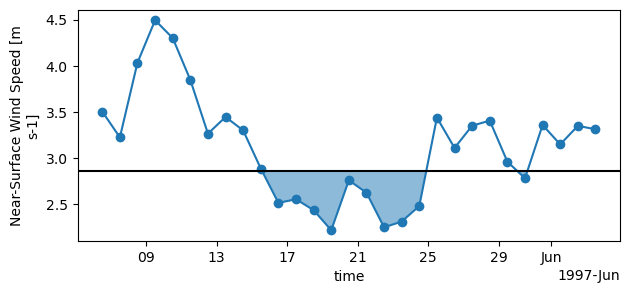

In [82]:
fig, ax = plt.subplots(1,1, figsize=(7,3))
duration, start = top_droughts[['WDDx', 'start_date']].iloc[0]
wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 10, 10)
plot_ts(ax, wind_ts, pctl10_obs)

15.879774305555555
19.185546875
18.47265625
19.1328125
19.30078125
18.767578125
18.302734375
18.517578125
20.904296875
19.97265625
20.5625
20.6640625


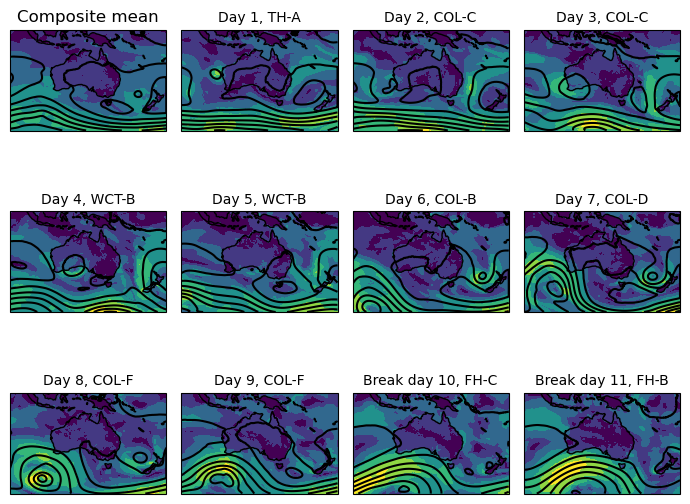

In [83]:
plot_event(top_droughts, 0)

z500, 300 meridional wind, weather objects, SWTs, blocking indices
solar: radiation

SWT: x: event ID; y: day of event.. http://www.weathermanbarnes.com/forecast_eIFS.html

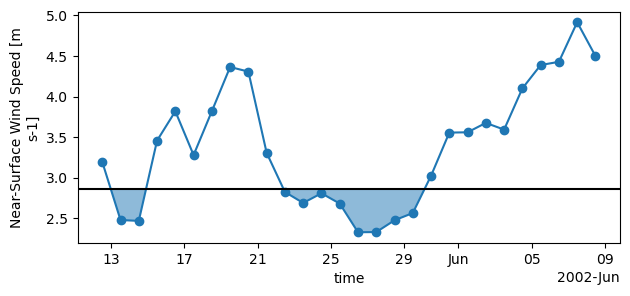

In [84]:
fig, ax = plt.subplots(1,1, figsize=(7,3))
duration, start = top_droughts[['WDDx', 'start_date']].iloc[1]
wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 10, 10)
plot_ts(ax, wind_ts, pctl10_obs)

15.383544921875
20.763671875
19.830078125
17.494140625
19.994140625
20.318359375
19.974609375
18.45703125
17.166015625
15.142578125
16.529296875


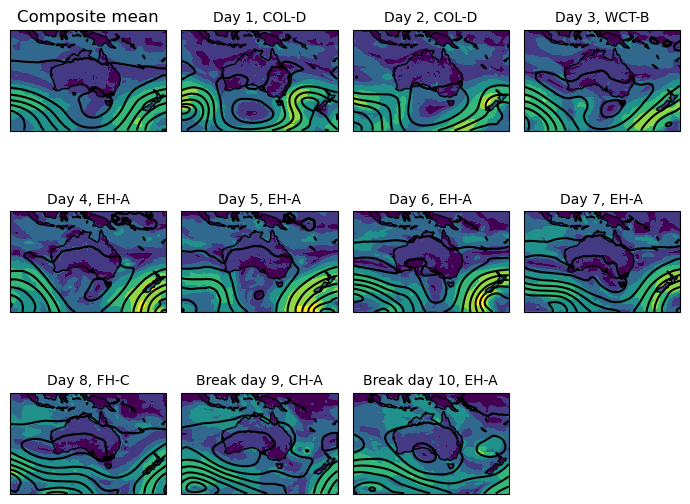

In [85]:
plot_event(top_droughts, 1)

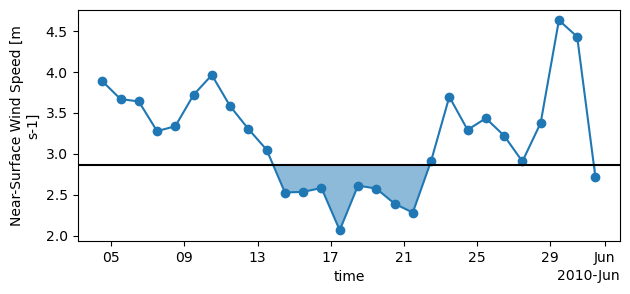

In [86]:
fig, ax = plt.subplots(1,1, figsize=(7,3))
duration, start = top_droughts[['WDDx', 'start_date']].iloc[2]
wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 10, 10)
plot_ts(ax, wind_ts, pctl10_obs)

14.080810546875
19.283203125
15.3671875
16.056640625
17.109375
18.6015625
16.31640625
17.939453125
16.908203125
18.587890625
19.173828125


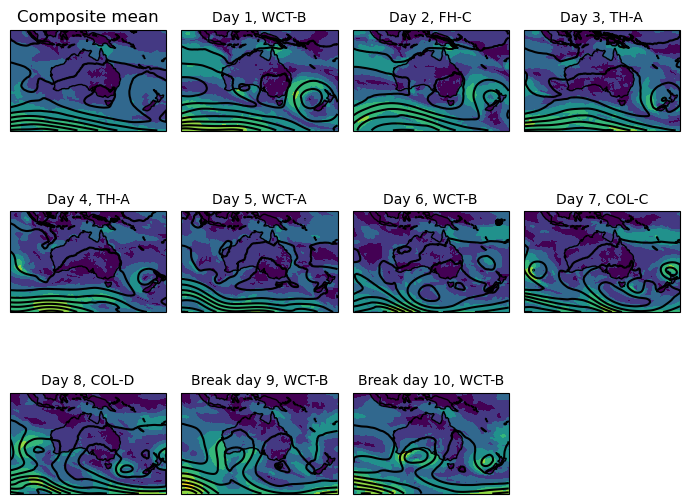

In [87]:
plot_event(top_droughts, 2)